# Superstore Sales Exploratory Data Analysis

This notebook explores the Superstore dataset to analyze sales performance, profitability, and key business insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

## Data Loading and Initial Inspection

Load the cleaned dataset and inspect the first rows.

In [3]:
df = pd.read_csv("../data/clean_superstore.csv", sep=";")

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,08.11.2016,11.11.2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,08.11.2016,11.11.2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,Hon Deluxe Fabric Upholstered Stacking Chairs....,731.9400,3,0.00,219.5820
2,3,CA-2016-138688,12.06.2016,16.06.2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,11.10.2015,18.10.2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,11.10.2015,18.10.2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Dataset Structure and Summary Statistics

Examine dataset structure, data types, and descriptive statistics.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["Postal Code"] = df["Postal Code"].astype(str)
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

In [35]:
df[["Sales","Quantity","Discount","Profit"]].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


## Sales Analysis

Analyze total sales across product categories.

In [10]:
sales_by_category = df.groupby("Category")["Sales"].sum()

sales_by_category

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

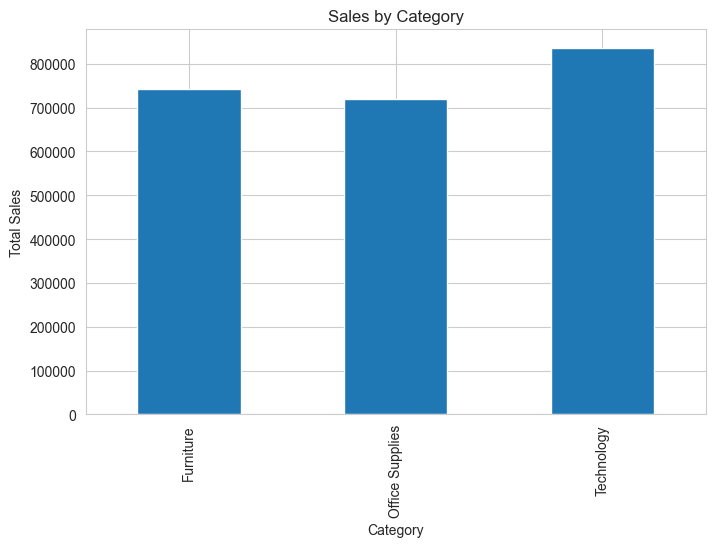

In [11]:
sales_by_category.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

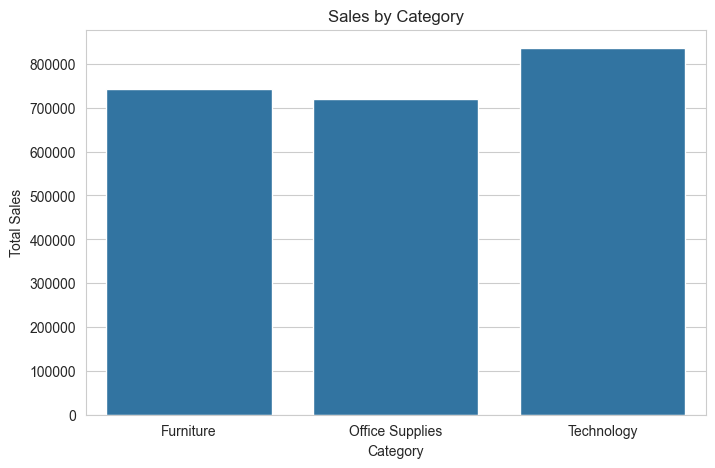

In [12]:
plt.figure()

sns.barplot(x=sales_by_category.index, y=sales_by_category.values)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.savefig("../visuals/sales_by_category.png")

plt.show()

**Insight:** Technology generates the highest total sales, followed by Furniture, while Office Supplies contribute the least revenue.

## Profitability Analysis

Analyze profit across regions, categories, and customer segments.

In [13]:
profit_by_region = df.groupby("Region")["Profit"].sum()

profit_by_region

Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64

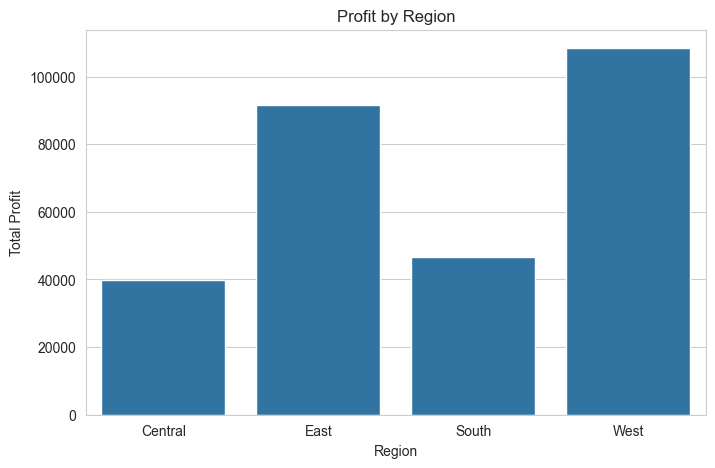

In [14]:
plt.figure()

sns.barplot(x=profit_by_region.index, y=profit_by_region.values)

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")

plt.savefig("../visuals/profit_by_region.png")

plt.show()

**Insight:** The West region generates the highest total profit, indicating strong sales performance and profitability in this region.

## Sales vs Profit

Explore the relationship between sales and profit.

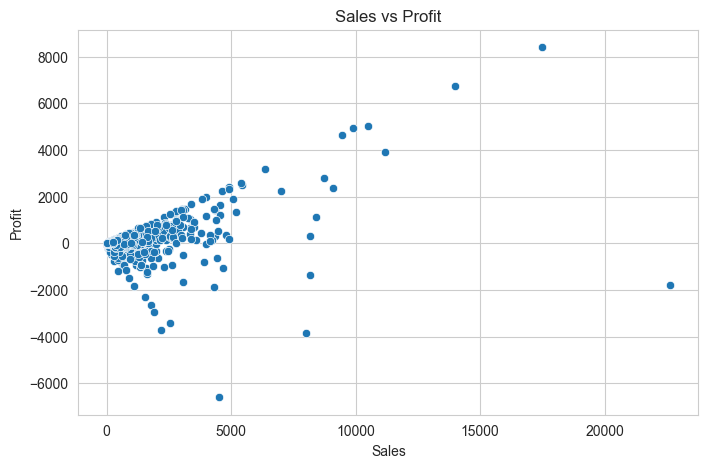

In [15]:
plt.figure()

sns.scatterplot(data=df, x="Sales", y="Profit")

plt.title("Sales vs Profit")

plt.savefig("../visuals/sales_vs_profit.png")

plt.show()

**Insight:** Most orders generate small profits, but some transactions with high discounts lead to negative profit.

## Top 10 Products by Sales
This analysis identifies the products with the highest total sales.

In [16]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

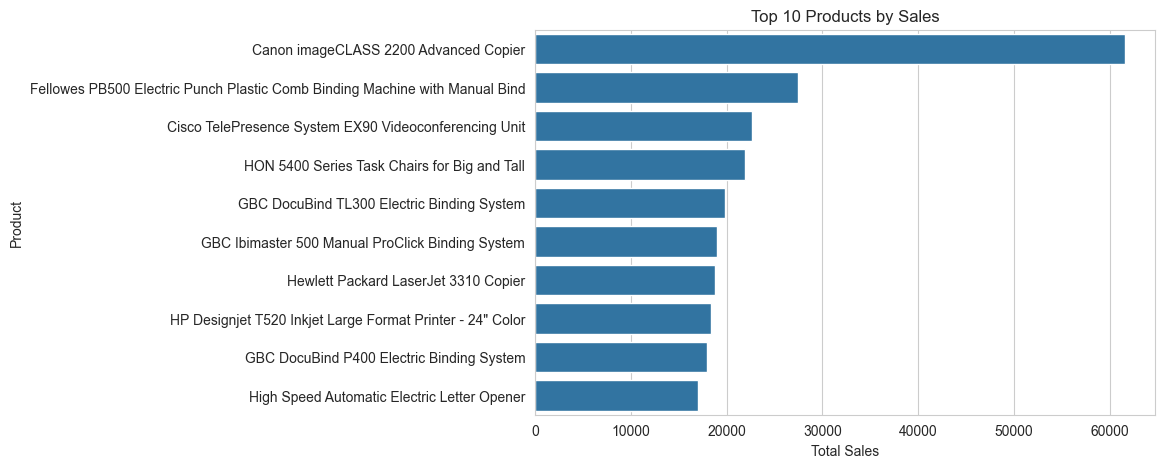

In [17]:
plt.figure()

sns.barplot(x=top_products.values, y=top_products.index)

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")

plt.savefig("../visuals/top_10_products_sales.png")

plt.show()

**Insight:** A small number of products generate a significant share of total sales, indicating that revenue is concentrated among top-selling items.

## Time Series Analysis

Analyze monthly sales trends over time.

In [18]:
df["Month"] = df["Order Date"].dt.to_period("M")

In [19]:
monthly_sales = df.groupby("Month")["Sales"].sum()

monthly_sales

Month
2014-01     14236.8950
2014-02      4519.8920
2014-03     55691.0090
2014-04     28295.3450
2014-05     23648.2870
2014-06     34595.1276
2014-07     33946.3930
2014-08     27909.4685
2014-09     81777.3508
2014-10     31453.3930
2014-11     78628.7167
2014-12     69545.6205
2015-01     18174.0756
2015-02     11951.4110
2015-03     38726.2520
2015-04     34195.2085
2015-05     30131.6865
2015-06     24797.2920
2015-07     28765.3250
2015-08     36898.3322
2015-09     64595.9180
2015-10     31404.9235
2015-11     75972.5635
2015-12     74919.5212
2016-01     18542.4910
2016-02     22978.8150
2016-03     51715.8750
2016-04     38750.0390
2016-05     56987.7280
2016-06     40344.5340
2016-07     39261.9630
2016-08     31115.3743
2016-09     73410.0249
2016-10     59687.7450
2016-11     79411.9658
2016-12     96999.0430
2017-01     43971.3740
2017-02     20301.1334
2017-03     58872.3528
2017-04     36521.5361
2017-05     44261.1102
2017-06     52981.7257
2017-07     45264.4160
2017-

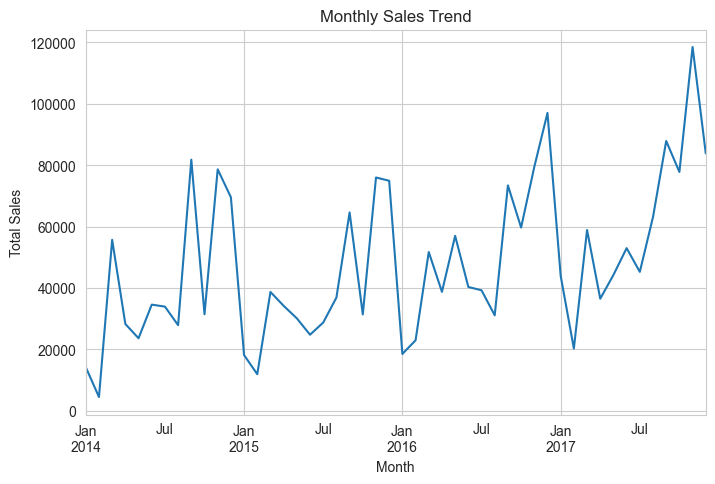

In [20]:
plt.figure()

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.savefig("../visuals/monthly_sales_trend.png")

plt.show()

**Insight:** Sales show an overall upward trend over time, indicating business growth across the observed period.

## Correlation Analysis

Examine relationships between key numerical variables.

In [21]:
correlation = df[["Sales", "Quantity", "Discount", "Profit"]].corr()

correlation

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200795,-0.028190,0.479064
Quantity,0.200795,1.000000,0.008623,0.066253
Discount,-0.028190,0.008623,1.000000,-0.219487
Profit,0.479064,0.066253,-0.219487,1.000000


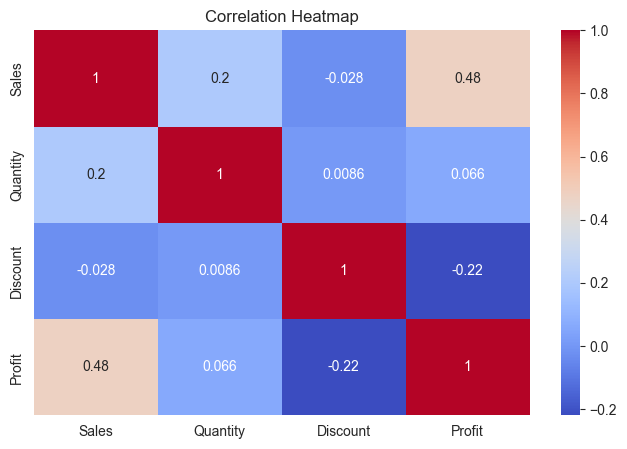

In [22]:
plt.figure()

sns.heatmap(correlation, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.savefig("../visuals/correlation_heatmap.png")

plt.show()

**Insight:** Discount shows a negative relationship with profit, suggesting that higher discounts are often associated with lower profitability.

## Profit by Category
Analyze total profit across product categories to understand which category is the most profitable.

In [23]:
profit_by_category = df.groupby("Category")["Profit"].sum()

profit_by_category

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64

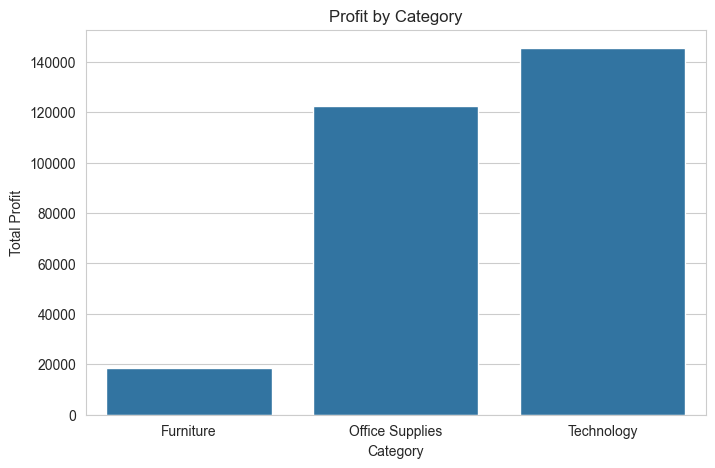

In [24]:
plt.figure()

sns.barplot(x=profit_by_category.index, y=profit_by_category.values)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.savefig("../visuals/profit_by_category.png")

plt.show()

**Insight:** Technology is the most profitable category, while Furniture generates lower profit relative to its sales.

## Loss Analysis

Identify loss-making orders and products.

In [25]:
loss_orders = df[df["Profit"] < 0]

loss_orders.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Month
3,4,US-2015-108966,2015-10-11,18.10.2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015-10
14,15,US-2015-118983,2015-11-22,26.11.2015,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,Central,OFF-AP-10002311,Office Supplies,Appliances,Holmes Replacement Filter for HEPA Air Cleaner...,68.8100,5,0.80,-123.8580,2015-11
15,16,US-2015-118983,2015-11-22,26.11.2015,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,Central,OFF-BI-10000756,Office Supplies,Binders,Storex DuraTech Recycled Plastic Frosted Binders,2.5440,3,0.80,-3.8160,2015-11
23,24,US-2017-156909,2017-07-16,18.07.2017,Second Class,SF-20065,Sandra Flanagan,Consumer,United States,Philadelphia,...,East,FUR-CH-10002774,Furniture,Chairs,Global Deluxe Stacking Chair. Gray,71.3720,2,0.30,-1.0196,2017-07
27,28,US-2015-150630,2015-09-17,21.09.2015,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,East,FUR-BO-10004834,Furniture,Bookcases,Riverside Palais Royal Lawyers Bookcase. Royal...,3083.4300,7,0.50,-1665.0522,2015-09


In [26]:
loss_orders.shape

(1871, 22)

In [27]:
loss_ratio = len(loss_orders) / len(df)

loss_ratio

0.18721232739643787

In [28]:
loss_products = df.groupby("Product Name")["Profit"].sum().sort_values().head(10)

loss_products

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64

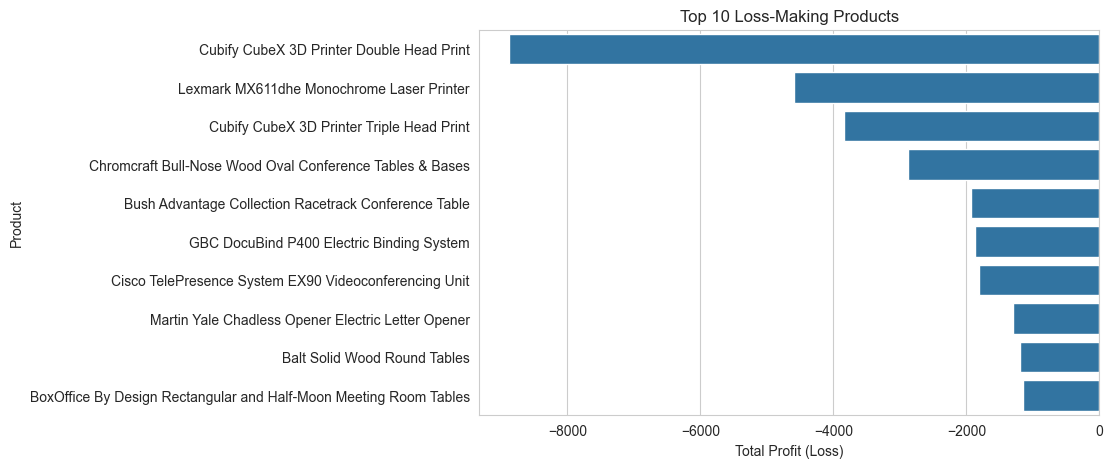

In [29]:
plt.figure()

sns.barplot(x=loss_products.values, y=loss_products.index)

plt.title("Top 10 Loss-Making Products")
plt.xlabel("Total Profit (Loss)")
plt.ylabel("Product")

plt.savefig("../visuals/top_10_loss_products.png")

plt.show()

**Insight:** Some products consistently generate losses, which may indicate pricing or discount strategy issues.

### Discount Impact on Profit
Compare the average discount for loss-making orders with the overall average discount.

In [30]:
discount_loss = df[df["Profit"] < 0]["Discount"].mean()

discount_loss

np.float64(0.48088722608230894)

In [31]:
discount_all = df["Discount"].mean()

discount_all

np.float64(0.15620272163297977)

**Insight:** Loss-making orders have significantly higher discounts than the overall average.

## Profit by Customer Segment
Analyze total profit generated by each customer segment.

In [32]:
profit_by_segment = df.groupby("Segment")["Profit"].sum()

profit_by_segment

Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64

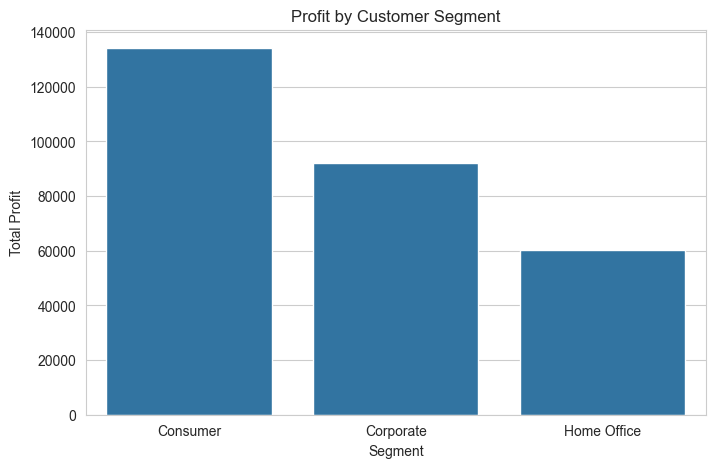

In [33]:
plt.figure()

sns.barplot(x=profit_by_segment.index, y=profit_by_segment.values)

plt.title("Profit by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Profit")

plt.savefig("../visuals/profit_by_segment.png")

plt.show()

**Insight:** The Consumer segment generates the highest total profit, indicating that individual customers represent the most valuable segment.